In [2]:
# Scraping Pokemon data from pokemon database and saving to CSV
import requests
from bs4 import BeautifulSoup
import pandas as pd

url = 'https://pokemondb.net/pokedex/all'
response = requests.get(url)
soup = BeautifulSoup(response.text, 'html.parser')

# Find the main standings table
table = soup.find('table')  
df = pd.read_html(str(table))[0]  # Convert HTML table to pandas DataFrame

# df.to_csv('pokedex.csv', index=False) 

C:\Users\yashb\AppData\Local\Temp\ipykernel_25836\4288941770.py:12: FutureWarning: Passing literal html to 'read_html' is deprecated and will be removed in a future version. To read from a literal string, wrap it in a 'StringIO' object.
  df = pd.read_html(str(table))[0]  # Convert HTML table to pandas DataFrame


In [3]:
df

,#,Name,Type,Total,HP,Attack,Defense,Sp. Atk,Sp. Def,Speed
0,1,Bulbasaur,Grass Poison,318,45,49,49,65,65,45
1,2,Ivysaur,Grass Poison,405,60,62,63,80,80,60
2,3,Venusaur,Grass Poison,525,80,82,83,100,100,80
3,3,Venusaur Mega Venusaur,Grass Poison,625,80,100,123,122,120,80
4,4,Charmander,Fire,309,39,52,43,60,50,65
...,...,...,...,...,...,...,...,...,...,...
1210,1023,Iron Crown,Steel Psychic,590,90,72,100,122,108,98
1211,1024,Terapagos Normal Form,Normal,450,90,65,85,65,85,60
1212,1024,Terapagos Terastal Form,Normal,600,95,95,110,105,110,85
1213,1024,Terapagos Stellar Form,Normal,700,160,105,110,130,110,85


In [13]:
# splitting 'Type' column into 'Type1' and 'Type2'
types_split = df['Type'].str.split(' ',expand=True)
df['Type1'] = types_split[0]
df['Type2'] = types_split[1]

In [14]:
# checking for overall data quality
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1215 entries, 0 to 1214
Data columns (total 12 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   #        1215 non-null   int64 
 1   Name     1215 non-null   object
 2   Type     1215 non-null   object
 3   Total    1215 non-null   int64 
 4   HP       1215 non-null   int64 
 5   Attack   1215 non-null   int64 
 6   Defense  1215 non-null   int64 
 7   Sp. Atk  1215 non-null   int64 
 8   Sp. Def  1215 non-null   int64 
 9   Speed    1215 non-null   int64 
 10  Type1    1215 non-null   object
 11  Type2    669 non-null    object
dtypes: int64(8), object(4)
memory usage: 114.0+ KB


In [15]:
# checking for missing values
df.isnull().sum()

#            0
Name         0
Type         0
Total        0
HP           0
Attack       0
Defense      0
Sp. Atk      0
Sp. Def      0
Speed        0
Type1        0
Type2      546
dtype: int64

In [16]:
# Visualizing Pokémon data

df.describe()

,#,Total,HP,Attack,Defense,Sp. Atk,Sp. Def,Speed
count,1215.000000,1215.000000,1215.000000,1215.000000,1215.000000,1215.000000,1215.000000,1215.000000
mean,501.735802,443.104527,71.244444,81.152263,75.007407,73.224691,72.441152,70.034568
std,298.979081,121.193406,26.927819,32.037134,30.740999,32.757152,27.578188,30.161298
min,1.000000,175.000000,1.000000,5.000000,5.000000,10.000000,20.000000,5.000000
25%,240.500000,332.000000,52.000000,57.000000,52.000000,50.000000,51.000000,45.000000
50%,495.000000,465.000000,70.000000,80.000000,70.000000,65.000000,70.000000,68.000000
75%,753.500000,521.000000,85.000000,100.000000,91.000000,95.000000,90.000000,91.000000
max,1025.000000,1125.000000,255.000000,190.000000,250.000000,194.000000,250.000000,200.000000


In [17]:
df['Type1'].value_counts()

Type1
Water       150
Normal      134
Grass       113
Bug          91
Psychic      82
Fire         76
Electric     74
Rock         68
Dark         56
Fighting     50
Poison       49
Dragon       49
Ghost        47
Ground       47
Steel        45
Ice          43
Fairy        31
Flying       10
Name: count, dtype: int64

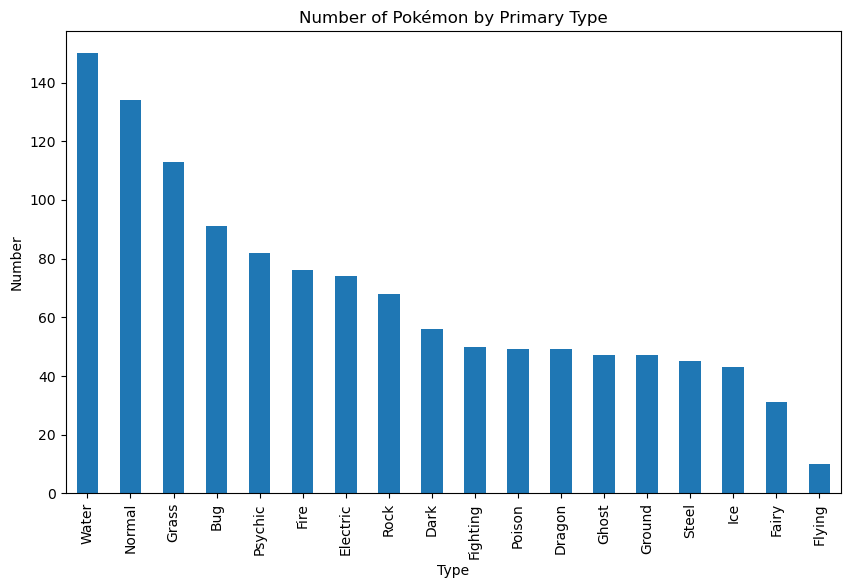

In [18]:
# visualizing the primary type distribution
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(10,6))
df['Type1'].value_counts().plot(kind='bar')
plt.title('Number of Pokémon by Primary Type')
plt.xlabel('Type')
plt.ylabel('Number')
plt.show()

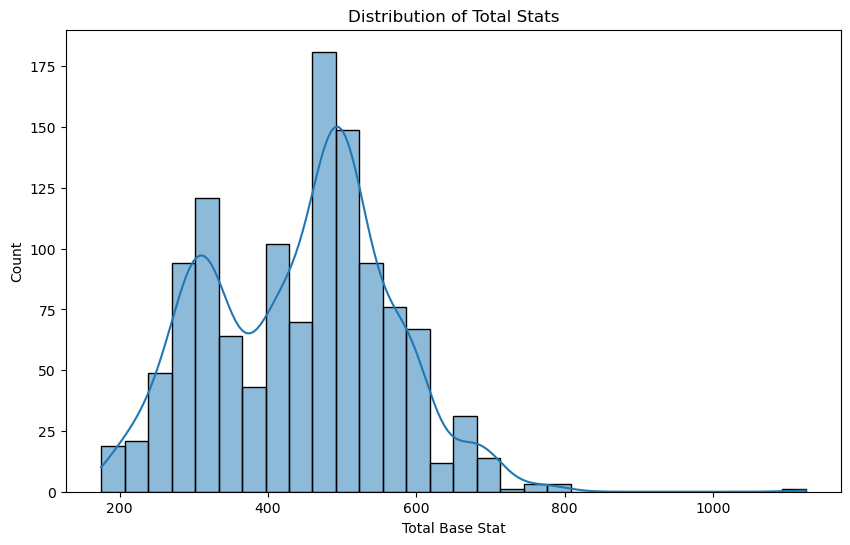

In [19]:
# visualizing the distribution of base stats of pokemon
plt.figure(figsize=(10,6))
sns.histplot(df['Total'], bins=30, kde=True)
plt.title('Distribution of Total Stats')
plt.xlabel('Total Base Stat')
plt.ylabel('Count')
plt.show()

As We can see in the boxplot below there are very less outliers for speed as compared to other stats because in the game speed is important but not directly useful hence not many extreme pokemons for speed. The same can be said about Sp.Def. stats as most players prefer attack based styles.

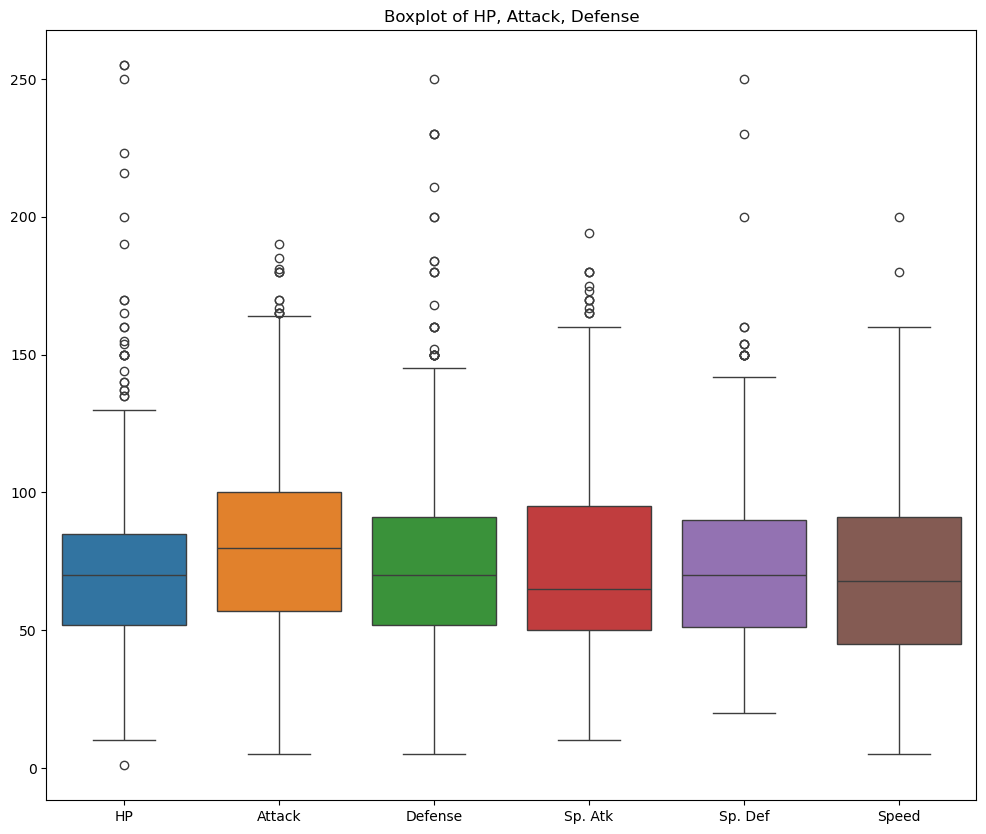

In [20]:
# visalizing boxplot of all stats
stats = ['HP', 'Attack', 'Defense', 'Sp. Atk', 'Sp. Def', 'Speed']
plt.figure(figsize=(12,10))
sns.boxplot(data=df[stats])
plt.title('Boxplot of HP, Attack, Defense')
plt.show()

The boxplot below is showing the stats distribution by primary type. Nearly all types have a similar mean except for the dragon type as Dragons are considered as legendary creatures and hence most of the Dragon types in the game are legendary hence their stats are skewed at a larger value as compared to other types.


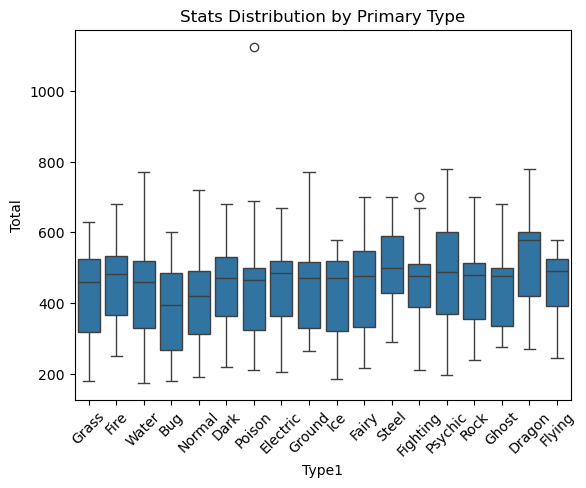

In [21]:
sns.boxplot(data=df, x='Type1', y='Total')
plt.title('Stats Distribution by Primary Type')
plt.xticks(rotation=45)
plt.show()

In [23]:
df = df.drop(columns=['Type', 'Type2'])  # Drop original Type column and Type2 as they are no longer needed
df = df.rename(columns={'Type1': 'Primary Type'})  # Rename Type1 to
df.to_csv('pokedex_cleaned.csv', index=False)  # Save cleaned DataFrame to CSV

In this Notebook I Scraped data about pokemon a famous franchise and used various plots to show the distribution of various stats in between pokemon of various types and also showed the differences between the stats and also the variety of pokemon according to their total stats.   